In [ ]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/credit_risk_clean.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ============================================
# CREDIT RISK EARLY WARNING SYSTEM
# Author: Albee Manoj Thomas
# Tool: Python — pandas, numpy
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.options.display.float_format = '{:.2f}'.format
pd.set_option('display.max_columns',None)

In [ ]:
# Load the clean dataset exported from MySQL
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (30000, 29)

Column names:
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default_next_month', 'late_payment_count', 'risk_tier', 'age_band', 'credit_limit_bucket']

First 5 rows:


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_next_month,late_payment_count,risk_tier,age_band,credit_limit_bucket
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1,2,risk_tier_medium,cohort_age_20_29,limit_below_50K
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1,2,risk_tier_medium,cohort_age_20_29,limit_100K_200K
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0,0,risk_tier_low,cohort_age_30_39,limit_50K_100K
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0,0,risk_tier_low,cohort_age_30_39,limit_50K_100K
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0,0,risk_tier_low,cohort_age_50_59,limit_50K_100K


In [ ]:
# Check for nulls and data types
print("=== NULL VALUES ===")
print(df.isnull().sum())

print("\n=== DATA TYPES ===")
print(df.dtypes)

print("\n=== BASIC STATISTICS ===")
display(df.describe())

=== NULL VALUES ===
ID                     0
LIMIT_BAL              0
SEX                    0
EDUCATION              0
MARRIAGE               0
AGE                    0
PAY_0                  0
PAY_2                  0
PAY_3                  0
PAY_4                  0
PAY_5                  0
PAY_6                  0
BILL_AMT1              0
BILL_AMT2              0
BILL_AMT3              0
BILL_AMT4              0
BILL_AMT5              0
BILL_AMT6              0
PAY_AMT1               0
PAY_AMT2               0
PAY_AMT3               0
PAY_AMT4               0
PAY_AMT5               0
PAY_AMT6               0
default_next_month     0
late_payment_count     0
risk_tier              0
age_band               0
credit_limit_bucket    0
dtype: int64

=== DATA TYPES ===
ID                      int64
LIMIT_BAL               int64
SEX                     int64
EDUCATION               int64
MARRIAGE                int64
AGE                     int64
PAY_0                   int64
PAY_2       

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_next_month,late_payment_count
count,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00
mean,15000.50,167484.32,1.60,1.85,1.55,35.49,-0.02,-0.13,-0.17,-0.22,-0.27,-0.29,51223.33,49179.08,47013.15,43262.95,40311.40,38871.76,5663.58,5921.16,5225.68,4826.08,4799.39,5215.50,0.22,0.83
std,8660.40,129747.66,0.49,0.79,0.52,9.22,1.12,1.20,1.20,1.17,1.13,1.15,73635.86,71173.77,69349.39,64332.86,60797.16,59554.11,16563.28,23040.87,17606.96,15666.16,15278.31,17777.47,0.42,1.55
min,1.00,10000.00,1.00,0.00,0.00,21.00,-2.00,-2.00,-2.00,-2.00,-2.00,-2.00,-165580.00,-69777.00,-157264.00,-170000.00,-81334.00,-339603.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,7500.75,50000.00,1.00,1.00,1.00,28.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,3558.75,2984.75,2666.25,2326.75,1763.00,1256.00,1000.00,833.00,390.00,296.00,252.50,117.75,0.00,0.00
50%,15000.50,140000.00,2.00,2.00,2.00,34.00,0.00,0.00,0.00,0.00,0.00,0.00,22381.50,21200.00,20088.50,19052.00,18104.50,17071.00,2100.00,2009.00,1800.00,1500.00,1500.00,1500.00,0.00,0.00
75%,22500.25,240000.00,2.00,2.00,2.00,41.00,0.00,0.00,0.00,0.00,0.00,0.00,67091.00,64006.25,60164.75,54506.00,50190.50,49198.25,5006.00,5000.00,4505.00,4013.25,4031.50,4000.00,0.00,1.00
max,30000.00,1000000.00,2.00,6.00,3.00,79.00,8.00,8.00,8.00,8.00,8.00,8.00,964511.00,983931.00,1664089.00,891586.00,927171.00,961664.00,873552.00,1684259.00,896040.00,621000.00,426529.00,528666.00,1.00,6.00


In [ ]:
# Overall default rate
total_clients = len(df)
total_defaults = df['default_next_month'].sum()
default_rate = round(total_defaults * 100 / total_clients, 2)

print(f"Total Clients:    {total_clients:,}")
print(f"Total Defaults:   {total_defaults:,}")
print(f"Overall Default Rate: {default_rate}%")

Total Clients:    30,000
Total Defaults:   6,636
Overall Default Rate: 22.12%


In [ ]:
# Average credit utilisation across 6 months
# Utilisation = Bill Amount / Credit Limit
df['avg_bill'] = df[['BILL_AMT1','BILL_AMT2','BILL_AMT3',
                      'BILL_AMT4','BILL_AMT5','BILL_AMT6']].mean(axis=1)

df['utilisation_rate'] = np.where(
    df['LIMIT_BAL'] > 0,
    df['avg_bill'] / df['LIMIT_BAL'],
    0
)

# Cap utilisation at 1 (some bills exceed limit due to interest)
df['utilisation_rate'] = df['utilisation_rate'].clip(0, 1)

print("Utilisation rate feature created")
print(df['utilisation_rate'].describe())

Utilisation rate feature created
count   30000.00
mean        0.37
std         0.34
min         0.00
25%         0.03
50%         0.28
75%         0.69
max         1.00
Name: utilisation_rate, dtype: float64


In [ ]:
# Is the client's utilisation getting worse over time?
# Positive slope = deteriorating, Negative slope = improving

bill_cols = ['BILL_AMT6','BILL_AMT5','BILL_AMT4',
             'BILL_AMT3','BILL_AMT2','BILL_AMT1']

def calc_slope(row):
    bills = row[bill_cols].values.astype(float)
    limit = row['LIMIT_BAL']
    if limit > 0:
        utilisation = bills / limit
    else:
        utilisation = bills
    x = np.arange(len(utilisation))
    slope = np.polyfit(x, utilisation, 1)[0]
    return round(slope, 6)

df['utilisation_trend_slope'] = df.apply(calc_slope, axis=1)

print("Utilisation trend slope feature created")
print(df['utilisation_trend_slope'].describe())

Utilisation trend slope feature created
count   30000.00
mean        0.02
std         0.06
min        -0.46
25%        -0.01
50%         0.00
75%         0.04
max         1.17
Name: utilisation_trend_slope, dtype: float64


In [ ]:
# How consistently does the client pay on time?
# 0 = always late, 1 = always on time

pay_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']

df['on_time_months'] = (df[pay_cols] <= 0).sum(axis=1)
df['payment_consistency_score'] = df['on_time_months'] / len(pay_cols)

print("Payment consistency score feature created")
print(df['payment_consistency_score'].describe())

Payment consistency score feature created
count   30000.00
mean        0.86
std         0.26
min         0.00
25%         0.83
50%         1.00
75%         1.00
max         1.00
Name: payment_consistency_score, dtype: float64


In [ ]:
# How recently was the client last late?
# 0 = late last month, 6 = never late in the period

def months_since_last_late(row):
    pay_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']
    for i, col in enumerate(pay_cols):
        if row[col] > 0:
            return i
    return 6

df['months_since_last_late'] = df.apply(months_since_last_late, axis=1)

print("Months since last late payment feature created")
print(df['months_since_last_late'].describe())

Months since last late payment feature created
count   30000.00
mean        4.29
std         2.56
min         0.00
25%         2.00
50%         6.00
75%         6.00
max         6.00
Name: months_since_last_late, dtype: float64


In [ ]:
# How much of their bill does the client actually pay?
# Higher ratio = healthier repayment behaviour

df['total_paid'] = df[['PAY_AMT1','PAY_AMT2','PAY_AMT3',
                        'PAY_AMT4','PAY_AMT5','PAY_AMT6']].sum(axis=1)

df['total_billed'] = df[['BILL_AMT1','BILL_AMT2','BILL_AMT3',
                          'BILL_AMT4','BILL_AMT5','BILL_AMT6']].sum(axis=1)

df['payment_to_bill_ratio'] = np.where(
    df['total_billed'] > 0,
    df['total_paid'] / df['total_billed'],
    1
)

df['payment_to_bill_ratio'] = df['payment_to_bill_ratio'].clip(0, 2)

print("Payment to bill ratio feature created")
print(df['payment_to_bill_ratio'].describe())

Payment to bill ratio feature created
count   30000.00
mean        0.38
std         0.46
min         0.00
25%         0.04
50%         0.11
75%         0.72
max         2.00
Name: payment_to_bill_ratio, dtype: float64


In [ ]:
# Flag statistically extreme clients using z-scores
# Z-score > 3 or < -3 = statistical outlier

from scipy import stats

features_for_zscore = ['LIMIT_BAL', 'utilisation_rate',
                        'payment_consistency_score', 'payment_to_bill_ratio']

for col in features_for_zscore:
    df[f'zscore_{col}'] = np.abs(stats.zscore(df[col]))

df['is_outlier'] = (
    (df['zscore_LIMIT_BAL'] > 3) |
    (df['zscore_utilisation_rate'] > 3) |
    (df['zscore_payment_consistency_score'] > 3) |
    (df['zscore_payment_to_bill_ratio'] > 3)
)

outlier_count = df['is_outlier'].sum()
print(f"Total outlier clients flagged: {outlier_count:,}")
print(f"Outlier rate: {round(outlier_count*100/len(df),2)}%")

Total outlier clients flagged: 2,065
Outlier rate: 6.88%


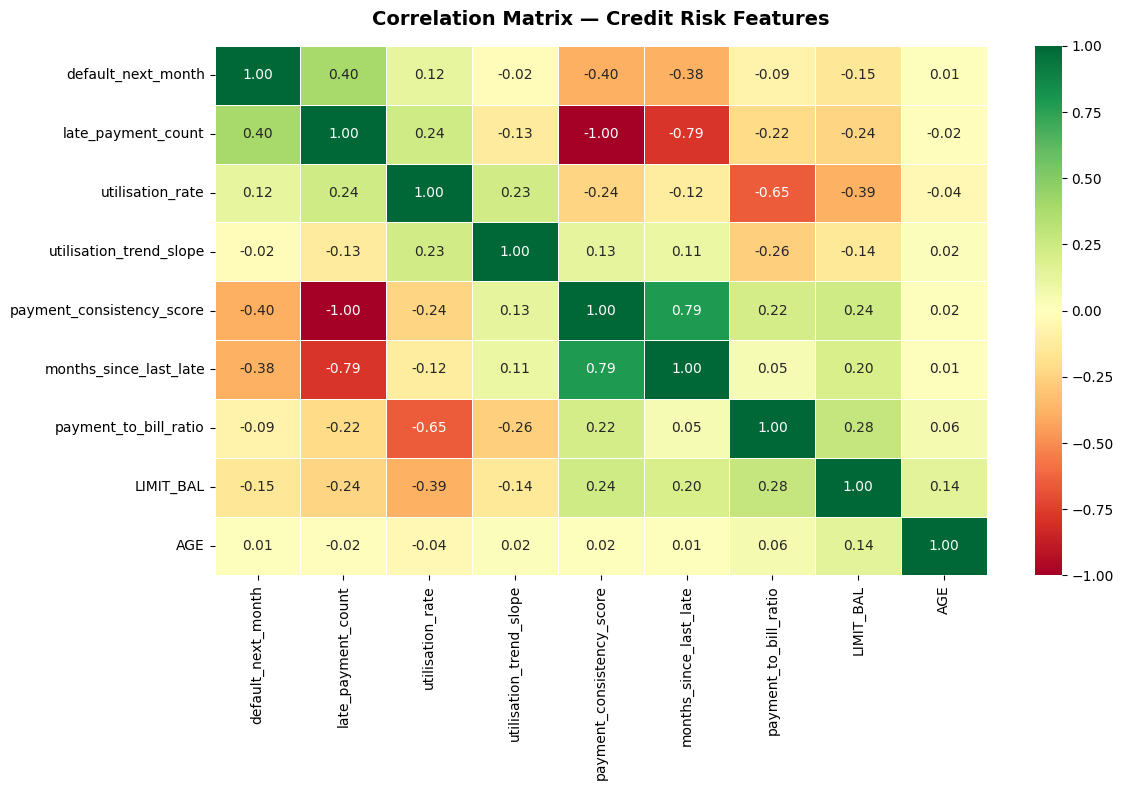

Correlation matrix saved


In [ ]:
# Which features correlate most strongly with default?

corr_features = [
    'default_next_month',
    'late_payment_count',
    'utilisation_rate',
    'utilisation_trend_slope',
    'payment_consistency_score',
    'months_since_last_late',
    'payment_to_bill_ratio',
    'LIMIT_BAL',
    'AGE'
]

corr_matrix = df[corr_features].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    annot_kws={'size': 10}
)
plt.title('Correlation Matrix — Credit Risk Features',
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Correlation matrix saved")

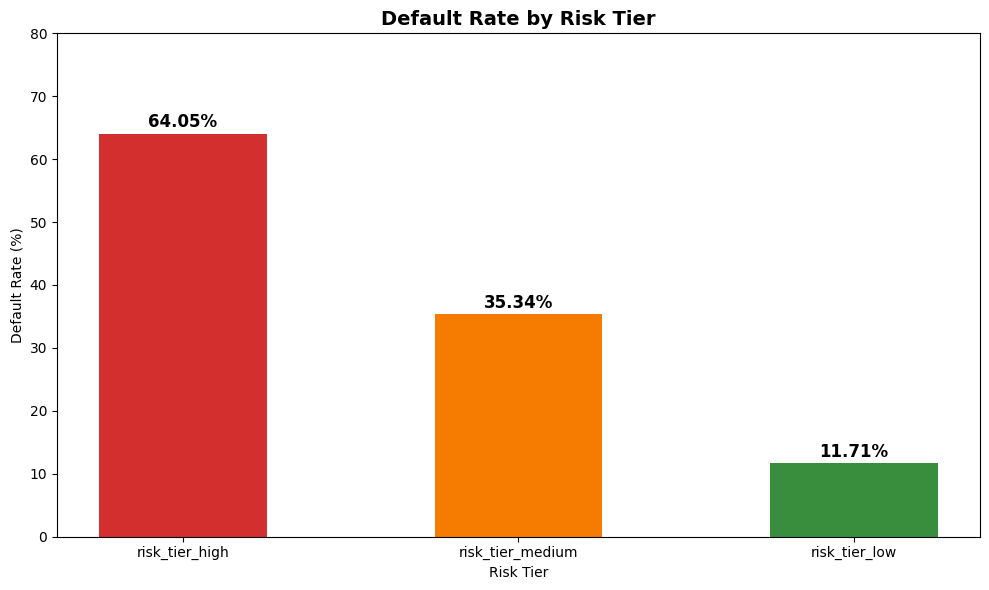

In [ ]:
risk_summary = df.groupby('risk_tier').agg(
    total_clients=('ID','count'),
    total_defaults=('default_next_month','sum')
).reset_index()

risk_summary['default_rate'] = round(
    risk_summary['total_defaults'] * 100 / risk_summary['total_clients'], 2)

risk_order = ['risk_tier_high','risk_tier_medium','risk_tier_low']
risk_summary['risk_tier'] = pd.Categorical(
    risk_summary['risk_tier'], categories=risk_order, ordered=True)
risk_summary = risk_summary.sort_values('risk_tier')

colors = ['#d32f2f','#f57c00','#388e3c']

plt.figure(figsize=(10, 6))
bars = plt.bar(risk_summary['risk_tier'],
               risk_summary['default_rate'],
               color=colors, width=0.5)

for bar, rate in zip(bars, risk_summary['default_rate']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f'{rate}%', ha='center', fontweight='bold', fontsize=12)

plt.title('Default Rate by Risk Tier', fontsize=14, fontweight='bold')
plt.ylabel('Default Rate (%)')
plt.xlabel('Risk Tier')
plt.ylim(0, 80)
plt.tight_layout()
plt.savefig('default_rate_by_risk_tier.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Export the fully engineered dataset
export_cols = [
    'ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE',
    'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6',
    'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
    'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
    'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
    'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
    'default_next_month',
    'late_payment_count',
    'risk_tier',
    'age_band',
    'credit_limit_bucket',
    'utilisation_rate',
    'utilisation_trend_slope',
    'payment_consistency_score',
    'months_since_last_late',
    'payment_to_bill_ratio',
    'is_outlier'
]

df_export = df[export_cols]
df_export.to_csv('credit_risk_final.csv', index=False)

print(f"Export complete: {df_export.shape[0]:,} rows, {df_export.shape[1]} columns")
print("File saved as: credit_risk_final.csv")
df_export.head()

Export complete: 30,000 rows, 35 columns
File saved as: credit_risk_final.csv


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_next_month,late_payment_count,risk_tier,age_band,credit_limit_bucket,utilisation_rate,utilisation_trend_slope,payment_consistency_score,months_since_last_late,payment_to_bill_ratio,is_outlier
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1,2,risk_tier_medium,cohort_age_20_29,limit_below_50K,0.06,0.04,0.67,0,0.09,False
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1,2,risk_tier_medium,cohort_age_20_29,limit_100K_200K,0.02,-0.00,0.67,1,0.29,False
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0,0,risk_tier_low,cohort_age_30_39,limit_50K_100K,0.19,0.02,1.00,6,0.11,False
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0,0,risk_tier_low,cohort_age_30_39,limit_50K_100K,0.77,0.09,1.00,6,0.04,False
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0,0,risk_tier_low,cohort_age_50_59,limit_50K_100K,0.36,-0.04,1.00,6,0.54,False
